## 1. Install & Import

In [ ]:
!pip install kaggle --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Download Kaggle A-Z Dataset
Upload your `kaggle.json` API key when prompted. Get it from: kaggle.com → Profile → Settings → API → Create New Token

In [ ]:
import os, json
from getpass import getpass

# Paste your Kaggle API key string when prompted (input is hidden)
# Get it from: kaggle.com → Profile → Settings → API → Create New Token
# It looks like: {"username":"yourname","key":"xxxxxxxxxxxxxxxx"}
kaggle_api_key = getpass('🔑 Paste your Kaggle API key JSON string: ')

# Write it to the expected location
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_api_key)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download and unzip
print('⬇️  Downloading dataset...')
os.system('kaggle datasets download -d sachinpatel21/az-handwritten-alphabets-in-csv-format')
os.system('unzip -o az-handwritten-alphabets-in-csv-format.zip')
print('✅ Done!')
os.system('ls *.csv')

🔑 Paste your Kaggle API key JSON string: ··········
⬇️  Downloading dataset...
✅ Done!


0

In [ ]:
# Load CSV — first column is label (0=A, 25=Z), remaining 784 are pixel values
print('Loading CSV (372k rows × 785 cols — may take ~30s)...')
data = pd.read_csv('A_Z Handwritten Data.csv', header=None).astype('float32')

train_y = data.iloc[:, 0].values.astype('int')
train_x = data.iloc[:, 1:].values

print(f'Loaded {len(train_x):,} samples')
print(f'Label range: {train_y.min()} – {train_y.max()} (0=A, 25=Z)')

Loading CSV (372k rows × 785 cols — may take ~30s)...
Loaded 372,451 samples
Label range: 0 – 25 (0=A, 25=Z)


## 3. Preprocess
Normalize, reshape, train/test split, and one-hot encode.

In [ ]:
from sklearn.model_selection import train_test_split

# Normalize to [0, 1]
train_x = train_x / 255.0

# Reshape to (N, 28, 28, 1)
train_x = train_x.reshape(-1, 28, 28, 1)

# Train / test split (90/10)
train_X, test_X, train_y_split, test_y_split = train_test_split(
    train_x, train_y, test_size=0.1, random_state=42, stratify=train_y
)

# One-hot encode
NUM_CLASSES = 26
train_Y = to_categorical(train_y_split, num_classes=NUM_CLASSES)
test_Y  = to_categorical(test_y_split,  num_classes=NUM_CLASSES)

word_dict = {i: chr(65 + i) for i in range(26)}

print(f'Train: {train_X.shape[0]:,}  Test: {test_X.shape[0]:,}')
print(f'Input shape: {train_X.shape[1:]}')

Train: 335,205  Test: 37,246
Input shape: (28, 28, 1)


## 4. Explore the Data

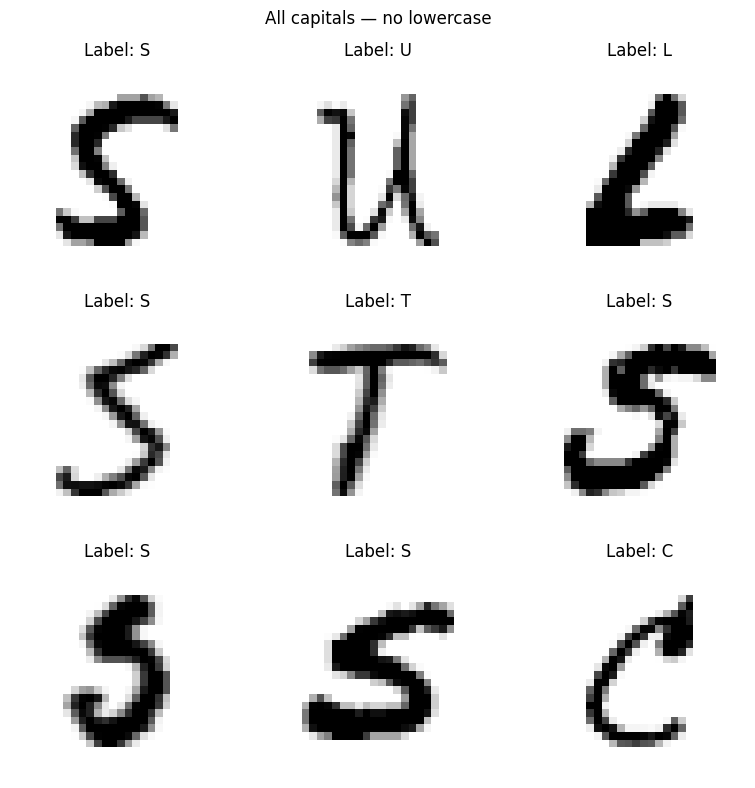

In [ ]:
word_dict = {i: chr(65 + i) for i in range(26)}

# Show 9 random samples — all should be capital letters
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax in axes.flatten():
    idx = np.random.randint(0, len(train_X))
    ax.imshow(train_X[idx].reshape(28, 28), cmap='Greys')
    ax.set_title(f'Label: {word_dict[train_y_split[idx]]}')
    ax.axis('off')
plt.suptitle('All capitals — no lowercase', fontsize=12)
plt.tight_layout()
plt.show()

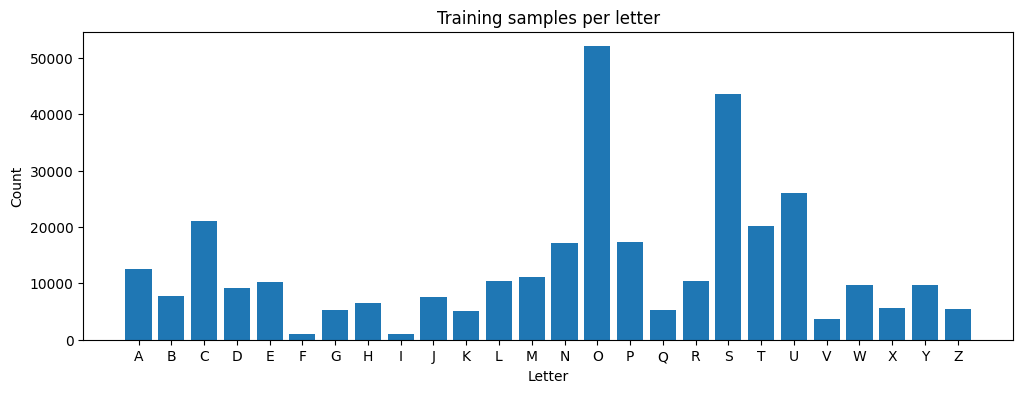

In [ ]:
counts = np.bincount(train_y_split)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(list(word_dict.values()), counts)
ax.set_xlabel('Letter')
ax.set_ylabel('Count')
ax.set_title('Training samples per letter')
plt.show()

## 5. Data Augmentation
Simulates variation in real handwriting — improves generalization.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_X)
print("Augmentation generator ready.")

Augmentation generator ready.


## 6. Build the Overfitting Model
Removed BatchNormalization and Dropout — deeper Dense head to maximize memorization.

In [ ]:
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    MaxPool2D((2, 2), strides=2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2),

    # Larger Dense head — more capacity to memorize
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850,586 (3.24 MB)

 Trainable params: 850,586 (3.24 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile & Train

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — were imported but unused in v1
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)

history = model.fit(train_X, train_Y, batch_size=128,
    epochs=50,
    validation_data=(test_X, test_Y),
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9580 - loss: 0.1465 - val_accuracy: 0.9823 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 2/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9854 - loss: 0.0509 - val_accuracy: 0.9873 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 3/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9894 - loss: 0.0369 - val_accuracy: 0.9900 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 4/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9914 - loss: 0.0288 - val_accuracy: 0.9887 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 5/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9931 - loss: 0.0232 - val_accuracy: 0.9923 - val_loss: 0.0256 - learning_rate: 0.0010
Epoch 6/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.9931 - val_loss: 0.0234 - learning_rate: 0.0010
Epoch 7/50
2619/2619 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9

## 8. Evaluate & Plot Training Curves

In [ ]:
val_loss, val_acc = model.evaluate(test_X, test_Y, verbose=0)
print(f"\n✅ Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"   Final Validation Loss    : {val_loss:.4f}")


✅ Final Validation Accuracy: 99.82%
   Final Validation Loss    : 0.0237


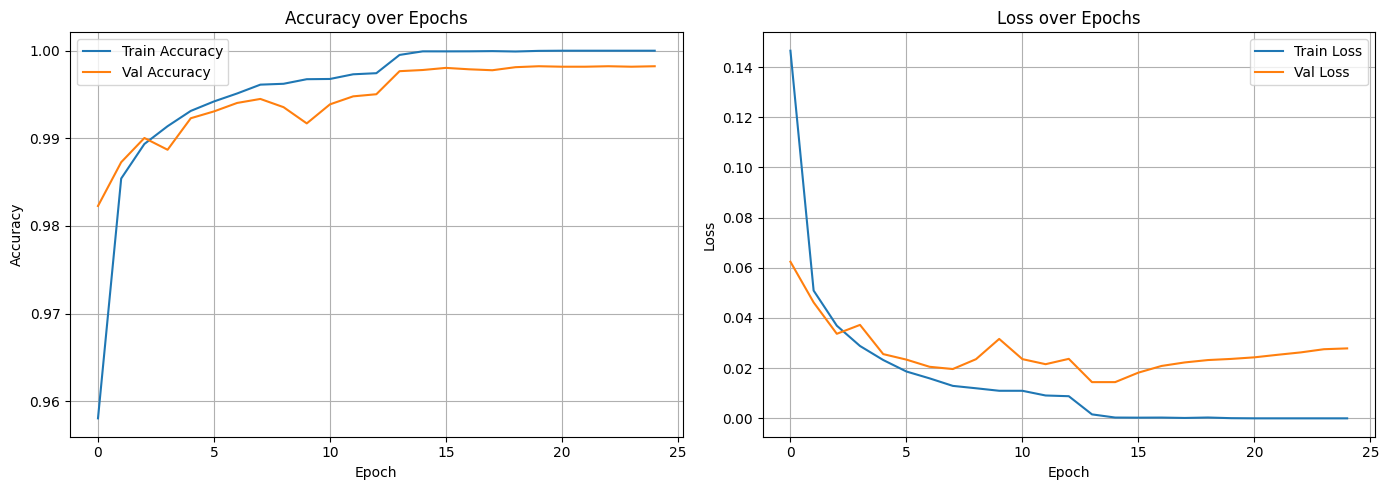

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 9. Predictions on Test Samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


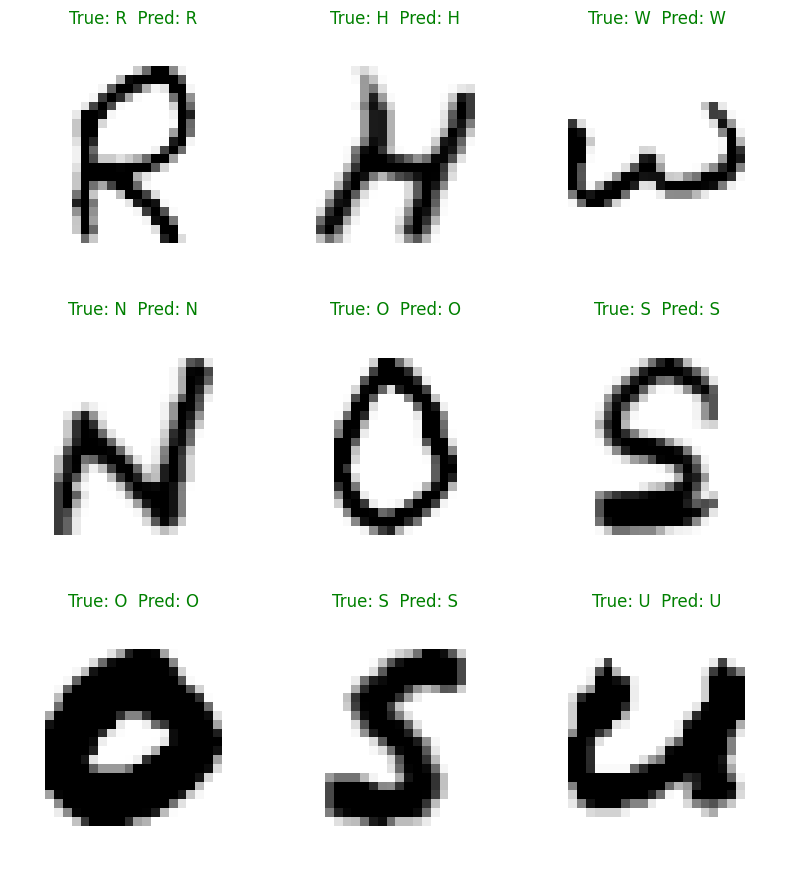

In [ ]:
preds = model.predict(test_X[:9])

fig, axes = plt.subplots(3, 3, figsize=(8, 9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(test_X[i].reshape(28, 28), cmap='Greys')
    true_label = word_dict[test_y_split[i]]
    pred_label = word_dict[np.argmax(preds[i])]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label}  Pred: {pred_label}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 10. Predict on Your Own Image
Upload a JPG/PNG of a handwritten letter and run this cell.

📁 Click Choose Files to upload your handwritten capital letter (JPG or PNG):


Saving IMG_7094.jpg to IMG_7094 (2).jpg
✅ Uploaded: IMG_7094 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


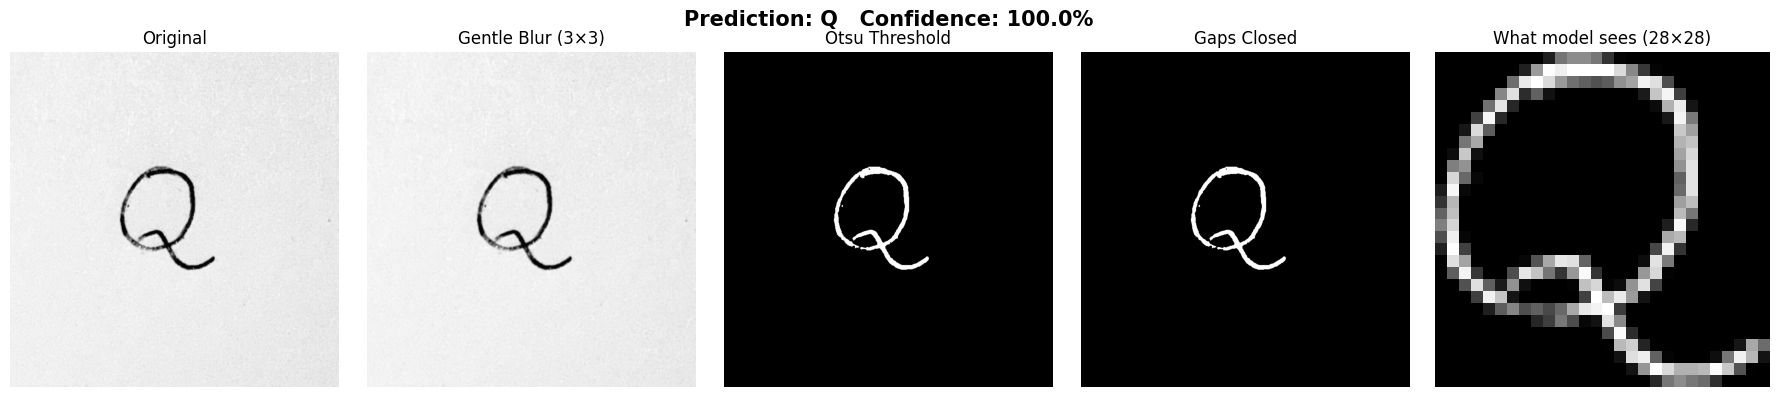


🔢 Top 3 predictions:
  1. Q  —  100.0%
  2. W  —  0.0%
  3. R  —  0.0%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Upload ---
print('📁 Click Choose Files to upload your handwritten capital letter (JPG or PNG):')
uploaded = files.upload()

if not uploaded:
    print('❌ No file uploaded.')
else:
    filename = list(uploaded.keys())[0]
    print(f'✅ Uploaded: {filename}')

    img      = cv2.imread(filename)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # STEP 1: Gentle blur — preserve stroke edges and smooth out minor paper texture
    img_blur = cv2.GaussianBlur(img_gray, (3, 3), 0)

    # STEP 2: Otsu's Thresholding — Automatically calculates optimal global threshold
    # Inverts the image so ink becomes white (255) and paper becomes black (0)
    ret, img_thresh = cv2.threshold(
        img_blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # STEP 3: Morphological closing — bridges ink gaps and pen-lift breaks
    kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img_closed = cv2.morphologyEx(img_thresh, cv2.MORPH_CLOSE, kernel)

    # STEP 4: Tight bounding box crop so the letter fills the 28x28 grid
    coords = cv2.findNonZero(img_closed)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = 4
        x1, y1 = max(x - pad, 0), max(y - pad, 0)
        x2, y2 = min(x + w + pad, img_closed.shape[1]), min(y + h + pad, img_closed.shape[0])
        img_cropped = img_closed[y1:y2, x1:x2]
    else:
        img_cropped = img_closed

    # STEP 5: Resize with INTER_AREA — best for shrinking, preserves strokes
    img_resized = cv2.resize(img_cropped, (28, 28), interpolation=cv2.INTER_AREA)
    img_norm    = img_resized.astype('float32') / 255.0
    img_input   = np.reshape(img_norm, (1, 28, 28, 1))

    # --- Predict ---
    pred_probs = model.predict(img_input)[0]
    pred_index = np.argmax(pred_probs)
    prediction = word_dict[pred_index]
    confidence = pred_probs[pred_index] * 100

    # --- Show all pipeline stages ---
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    for ax, img_stage, title in zip(axes,
        [img_rgb, img_blur, img_thresh, img_closed, img_norm.reshape(28,28)],
        ['Original', 'Gentle Blur (3×3)', 'Otsu Threshold', 'Gaps Closed', 'What model sees (28×28)']):

        # Changed 'Greys' to 'gray' so the visual properly shows 0 as black and 255 as white
        ax.imshow(img_stage, cmap='gray' if img_stage.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')

    plt.suptitle(f'Prediction: {prediction}   Confidence: {confidence:.1f}%',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Top 3 guesses
    top3 = np.argsort(pred_probs)[::-1][:3]
    print('\n🔢 Top 3 predictions:')
    for rank, idx in enumerate(top3, 1):
        print(f'  {rank}. {word_dict[idx]}  —  {pred_probs[idx]*100:.1f}%')

## 11. Save the Model

In [ ]:
model.save('alesha_capital_letter_rcgn.h5')
print("Model saved as alesha_capital_letter_rcgn.h5")

# Optional: download it to your local machine
from google.colab import files
files.download('alesha_capital_letter_rcgn.h5')

Model saved as alesha_capital_letter_rcgn.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive

# STEP 1: Mount your Google Drive to the Colab environment
# This will prompt you to log in and grant access
drive.mount('/content/drive')

# STEP 2: Define the path in your Google Drive where you want to save it.
# '/content/drive/MyDrive/' is the root folder of your Drive.
save_path = '/content/drive/MyDrive/alesha_capital_letter_rcgn.h5'

# STEP 3: Save the model directly to that path
model.save(save_path)
print(f"✅ Model successfully saved to Google Drive at: {save_path}")

Mounted at /content/drive
✅ Model successfully saved to Google Drive at: /content/drive/MyDrive/alesha_capital_letter_rcgn.h5
